# 📘 Week 1 Assignment — ML Foundations

**Topics Covered:** Python · NumPy · Pandas · Linear Algebra · Statistics · Probability Theory

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from io import StringIO

plt.rcParams['figure.figsize'] = (9, 4)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
print('All imports OK ✓')

All imports OK ✓


---
## Part 1 — Python Fundamentals

### 1.1 Data Types & Control Flow

In [2]:
def classify_number(n):
    """
    Classifies a number into one of four categories.
    Uses if/elif/else control flow to check conditions in order.
    """
    if n < 0:
        return "negative"
    elif n == 0:
        return "zero"
    elif n <= 10:
        return "small positive"
    else:
        return "large positive"

# Tests
assert classify_number(-5) == "negative"
assert classify_number(0)  == "zero"
assert classify_number(7)  == "small positive"
assert classify_number(42) == "large positive"
print("1.1 passed ✓")

1.1 passed ✓


### 1.2 Data Structures

In [3]:
words = ['apple', 'banana', 'cherry', 'apple', 'date', 'banana', 'apple']

# 1. word_count dict — loop through each word, increment counter
word_count = {}
for word in words:
    word_count[word] = word_count.get(word, 0) + 1

# 2. unique_words set — sets automatically remove duplicates
unique_words = set(words)

# 3. long_words — list comprehension filters words with length > 5
long_words = [w for w in words if len(w) > 5]

# Tests
assert word_count == {'apple': 3, 'banana': 2, 'cherry': 1, 'date': 1}
assert unique_words == {'apple', 'banana', 'cherry', 'date'}
assert set(long_words) == {'banana', 'cherry'}
print("1.2 passed ✓")
print(f"word_count: {word_count}")
print(f"unique_words: {unique_words}")
print(f"long_words: {long_words}")

1.2 passed ✓
word_count: {'apple': 3, 'banana': 2, 'cherry': 1, 'date': 1}
unique_words: {'date', 'apple', 'cherry', 'banana'}
long_words: ['banana', 'cherry', 'banana']


### 1.3 Exceptions

In [4]:
def safe_divide(a, b):
    """
    Safely divides two numbers.
    - Raises TypeError if inputs are not numeric (int or float)
    - Returns None on division by zero
    - Returns a/b otherwise
    """
    # Check types FIRST before attempting division
    if not isinstance(a, (int, float)) or not isinstance(b, (int, float)):
        raise TypeError("Inputs must be numeric")
    try:
        return a / b
    except ZeroDivisionError:
        return None

# Tests
assert safe_divide(10, 2) == 5.0
assert safe_divide(5, 0) is None
try:
    safe_divide('x', 2)
    assert False, "Should have raised TypeError"
except TypeError as e:
    assert str(e) == "Inputs must be numeric"
print("1.3 passed ✓")

1.3 passed ✓


### 1.4 Functions & Lambdas

In [5]:
def apply_twice(f, x):
    """Applies function f to x twice: f(f(x))"""
    return f(f(x))

# Lambda: an anonymous single-expression function
triple = lambda x: x * 3

# apply_twice(triple, 4) → triple(triple(4)) → triple(12) → 36
result = apply_twice(triple, 4)
assert result == 36, f"Expected 36, got {result}"
print("1.4 passed ✓")
print(f"apply_twice(triple, 4) = {result}")

1.4 passed ✓
apply_twice(triple, 4) = 36


---
## Part 2 — NumPy

### 2.1 Array Creation & Shapes

In [6]:
# arange(12) creates [0, 1, 2, ..., 11]
arr1d = np.arange(12)

# reshape rearranges elements without copying — total elements must stay 12
arr2d = arr1d.reshape(3, 4)    # 3 rows × 4 cols = 12
arr3d = arr1d.reshape(2, 2, 3) # 2 × 2 × 3 = 12

print(f"arr1d: shape={arr1d.shape}, ndim={arr1d.ndim}, dtype={arr1d.dtype}")
print(f"arr2d: shape={arr2d.shape}, ndim={arr2d.ndim}, dtype={arr2d.dtype}")
print(f"arr3d: shape={arr3d.shape}, ndim={arr3d.ndim}, dtype={arr3d.dtype}")

# Tests
assert arr1d.shape == (12,)
assert arr2d.shape == (3, 4)
assert arr3d.shape == (2, 2, 3)
print("2.1 passed ✓")
print(f"arr2d:\n{arr2d}")
print(f"arr3d:\n{arr3d}")

arr1d: shape=(12,), ndim=1, dtype=int64
arr2d: shape=(3, 4), ndim=2, dtype=int64
arr3d: shape=(2, 2, 3), ndim=3, dtype=int64
2.1 passed ✓
arr2d:
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
arr3d:
[[[ 0  1  2]
  [ 3  4  5]]

 [[ 6  7  8]
  [ 9 10 11]]]


### 2.2 Indexing & Slicing

In [7]:
# arr2d looks like:
# [[ 0,  1,  2,  3],
#  [ 4,  5,  6,  7],   ← row index 1 (second row)
#  [ 8,  9, 10, 11]]
#           ↑ col index 2 (third column)

# 1. Second row: index 1
row2 = arr2d[1]          # → [4, 5, 6, 7]

# 2. Third column: all rows (:), column index 2
col3 = arr2d[:, 2]       # → [2, 6, 10]

# 3. Bottom-right 2×2: rows 1..2, cols 2..3
sub  = arr2d[1:, 2:]     # → [[6,7],[10,11]]

# 4. Boolean indexing: create a mask where condition is True
gt7  = arr2d[arr2d > 7]  # → [8, 9, 10, 11]

# Tests
assert list(row2) == [4, 5, 6, 7]
assert list(col3) == [2, 6, 10]
assert sub.shape == (2, 2)
assert list(gt7) == [8, 9, 10, 11]
print("2.2 passed ✓")
print(f"row2={row2}, col3={col3}, sub=\n{sub}, gt7={gt7}")

2.2 passed ✓
row2=[4 5 6 7], col3=[ 2  6 10], sub=
[[ 6  7]
 [10 11]], gt7=[ 8  9 10 11]


### 2.3 Operations & Dot Product

In [8]:
A = np.array([[1, 2], [3, 4]])
B = np.array([[5, 6], [7, 8]])

# Element-wise: multiply corresponding elements
C = A * B          # [[1*5, 2*6], [3*7, 4*8]] = [[5,12],[21,32]]

# Matrix multiplication: row · column dot products
D = A @ B          # Standard linear algebra matrix product

# Dot product of 1D vectors: sum of element-wise products
dp = np.dot(np.array([1, 2, 3]), np.array([4, 5, 6]))  # 1*4+2*5+3*6 = 32

# Scalar multiplication: multiply every element by 3
E = A * 3

# Tests
assert np.array_equal(C, [[5,12],[21,32]])
assert np.array_equal(D, [[19,22],[43,50]])
assert dp == 32
assert np.array_equal(E, [[3,6],[9,12]])
print("2.3 passed ✓")
print(f"C (element-wise):\n{C}")
print(f"D (matrix mult):\n{D}")
print(f"dot product: {dp}")
print(f"E (scalar×3):\n{E}")

2.3 passed ✓
C (element-wise):
[[ 5 12]
 [21 32]]
D (matrix mult):
[[19 22]
 [43 50]]
dot product: 32
E (scalar×3):
[[ 3  6]
 [ 9 12]]


---
## Part 3 — Pandas

In [9]:
# Load dataset — do not modify this cell
CSV_DATA = """employee_id,name,department,salary,age,years_exp,performance
1,Alice,Engineering,95000,30,5,4.2
2,Bob,Marketing,72000,35,8,3.8
3,Carol,Engineering,88000,28,3,4.5
4,Dave,HR,61000,42,15,3.1
5,Eve,Engineering,102000,38,12,4.8
6,Frank,Marketing,68000,29,4,3.5
7,Grace,HR,,31,6,3.9
8,Hank,Engineering,91000,45,20,4.1
9,Iris,Marketing,75000,,7,4.0
10,Jack,Engineering,85000,33,8,
"""
df = pd.read_csv(StringIO(CSV_DATA))
print(f"Shape: {df.shape}")
df.head(10)

Shape: (10, 7)


,employee_id,name,department,salary,age,years_exp,performance
0,1,Alice,Engineering,95000.0,30.0,5,4.2
1,2,Bob,Marketing,72000.0,35.0,8,3.8
2,3,Carol,Engineering,88000.0,28.0,3,4.5
3,4,Dave,HR,61000.0,42.0,15,3.1
4,5,Eve,Engineering,102000.0,38.0,12,4.8
5,6,Frank,Marketing,68000.0,29.0,4,3.5
6,7,Grace,HR,NaN,31.0,6,3.9
7,8,Hank,Engineering,91000.0,45.0,20,4.1
8,9,Iris,Marketing,75000.0,NaN,7,4.0
9,10,Jack,Engineering,85000.0,33.0,8,NaN


### 3.1 DataFrames vs Series

In [10]:
# A Series is a single column — 1D labeled array
salary_series = df['salary']

# A DataFrame is a 2D table — selecting multiple columns returns a DataFrame
name_dept_df = df[['name', 'department']]

assert isinstance(salary_series, pd.Series)
assert isinstance(name_dept_df, pd.DataFrame)
print(f"salary_series type: {type(salary_series).__name__}")
print(f"name_dept_df type: {type(name_dept_df).__name__}")
print("3.1 passed ✓")

salary_series type: Series
name_dept_df type: DataFrame
3.1 passed ✓


### 3.2 iloc & loc

In [11]:
# iloc = integer-based (positional) indexing — like numpy
# rows 2,3,4 (index positions) and columns 0,1,2
iloc_result = df.iloc[2:5, 0:3]   # end is exclusive: 2,3,4 and 0,1,2

# loc = label-based indexing — uses actual index values
# Note: loc end is INCLUSIVE (5 and 6 both included)
loc_result = df.loc[5:6, ['name', 'salary']]

assert iloc_result.shape == (3, 3)
assert list(loc_result.columns) == ['name', 'salary']
print("3.2 passed ✓")
print("iloc_result:")
display(iloc_result)
print("loc_result:")
display(loc_result)

3.2 passed ✓
iloc_result:


,employee_id,name,department
2,3,Carol,Engineering
3,4,Dave,HR
4,5,Eve,Engineering


loc_result:


,name,salary
5,Frank,68000.0
6,Grace,NaN


### 3.3 Filtering & Group By

In [12]:
# Boolean filtering: combine conditions with & (AND) — wrap each in parentheses!
senior_eng = df[(df['department'] == 'Engineering') & (df['salary'] > 90000)]

# groupby: split → apply → combine
# agg lets you compute multiple aggregations at once, with custom column names
dept_stats = (
    df.groupby('department')
    .agg(
        mean_salary=('salary', 'mean'),
        mean_performance=('performance', 'mean')
    )
    .sort_values('mean_salary', ascending=False)
)

print(f"Senior engineers: {len(senior_eng)}")
display(senior_eng[['name', 'salary']])
print("\nDept stats (sorted by mean salary):")
display(dept_stats)

Senior engineers: 3


,name,salary
0,Alice,95000.0
4,Eve,102000.0
7,Hank,91000.0



Dept stats (sorted by mean salary):


,mean_salary,mean_performance
department,,
Engineering,92200.000000,4.400000
Marketing,71666.666667,3.766667
HR,61000.000000,3.500000


### 3.4 Handling Missing Data

In [13]:
print("Missing values before:")
print(df.isnull().sum())

df_filled = df.copy()  # always work on a copy to preserve original

# Fill salary NaN with the median (robust to outliers, better than mean for skewed data)
df_filled['salary'] = df_filled['salary'].fillna(df_filled['salary'].median())

# Fill age NaN with mean age, rounded to nearest integer
df_filled['age'] = df_filled['age'].fillna(round(df_filled['age'].mean()))

# Drop rows where performance is missing (can't impute target-adjacent columns reliably)
df_filled = df_filled.dropna(subset=['performance'])

print("\nMissing values after:")
print(df_filled.isnull().sum())
assert df_filled.isnull().sum().sum() == 0, "Still has nulls!"
print("3.4 passed ✓")

Missing values before:
employee_id    0
name           0
department     0
salary         1
age            1
years_exp      0
performance    1
dtype: int64

Missing values after:
employee_id    0
name           0
department     0
salary         0
age            0
years_exp      0
performance    0
dtype: int64
3.4 passed ✓


---
## Part 4 — Linear Algebra

### 4.1 Vectors & Matrices as Data

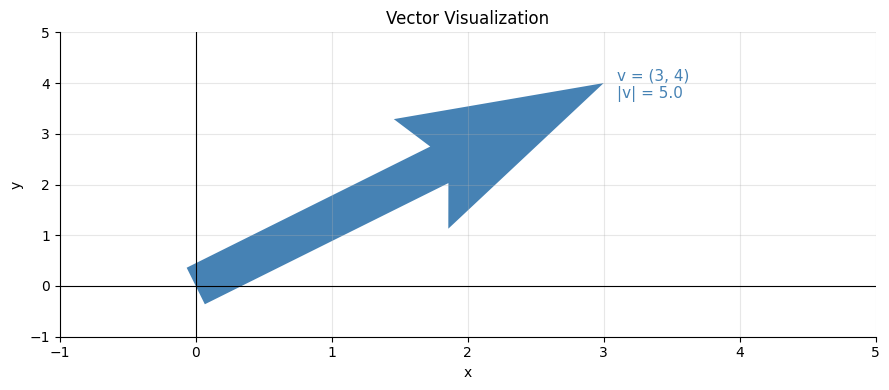

4.1 passed ✓  |v| = 5.0


In [14]:
v = np.array([3, 4])

# L2 norm = sqrt(3² + 4²) = sqrt(9+16) = sqrt(25) = 5.0
norm_v = np.linalg.norm(v)

# Any non-trivial 3×3 matrix
M = np.array([[1, 2, 3],
              [4, 5, 6],
              [7, 8, 9]])

# Plot vector as arrow from origin
fig, ax = plt.subplots()
ax.quiver(0, 0, v[0], v[1], angles='xy', scale_units='xy', scale=1,
          color='steelblue', width=0.05)
ax.annotate(f'v = ({v[0]}, {v[1]})\n|v| = {norm_v}', xy=(v[0]+0.1, v[1]-0.3),
            fontsize=11, color='steelblue')
ax.set_xlim(-1, 5); ax.set_ylim(-1, 5)
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Vector Visualization')
ax.axhline(0, color='k', lw=0.8); ax.axvline(0, color='k', lw=0.8)
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

assert abs(norm_v - 5.0) < 1e-9
assert M.shape == (3, 3)
print(f"4.1 passed ✓  |v| = {norm_v}")

### 4.2 Matrix Operations in Practice

In [15]:
P = np.array([[2, 1], [0, 3]])
Q = np.array([[1, 4], [2, 0]])

PplusQ   = P + Q       # element-wise addition
scalar3P = 3 * P       # scalar multiplication
PQ       = P @ Q       # matrix multiplication P×Q
QP       = Q @ P       # matrix multiplication Q×P (different!)

print(f"P + Q =\n{PplusQ}")
print(f"3*P =\n{scalar3P}")
print(f"P @ Q =\n{PQ}")
print(f"Q @ P =\n{QP}")
print(f"PQ == QP? {np.array_equal(PQ, QP)}  ← matrix mult is NOT commutative!")

assert not np.array_equal(PQ, QP), "They should differ!"
print("4.2 passed ✓")

P + Q =
[[3 5]
 [2 3]]
3*P =
[[6 3]
 [0 9]]
P @ Q =
[[4 8]
 [6 0]]
Q @ P =
[[ 2 13]
 [ 4  2]]
PQ == QP? False  ← matrix mult is NOT commutative!
4.2 passed ✓


### 4.3 Eigenvalues & Eigenvectors

Eigenvalues: [5. 2.]
Eigenvectors (columns):
[[ 0.70710678 -0.4472136 ]
 [ 0.70710678  0.89442719]]

Verification: A @ v  vs  λ * v
  λ=5.00: A@v=[3.5355 3.5355], λ*v=[3.5355 3.5355], match=True
  λ=2.00: A@v=[-0.8944  1.7889], λ*v=[-0.8944  1.7889], match=True


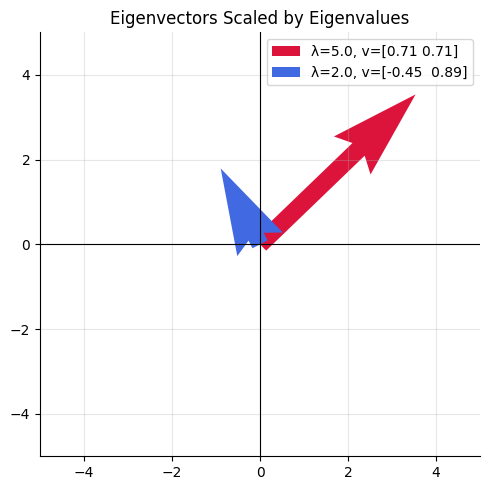

4.3 passed ✓


In [16]:
A = np.array([[4, 1],
              [2, 3]], dtype=float)

# np.linalg.eig returns:
#   eigenvalues: 1D array of λ values
#   eigenvectors: 2D array where each COLUMN is an eigenvector
eigenvalues, eigenvectors = np.linalg.eig(A)

print(f"Eigenvalues: {eigenvalues}")
print(f"Eigenvectors (columns):\n{eigenvectors}")

# Verify Av = λv for each eigenpair
print("\nVerification: A @ v  vs  λ * v")
for i in range(len(eigenvalues)):
    lam = eigenvalues[i]
    vec = eigenvectors[:, i]    # column i is the i-th eigenvector
    Av  = A @ vec
    lv  = lam * vec
    match = np.allclose(Av, lv)
    print(f"  λ={lam:.2f}: A@v={Av.round(4)}, λ*v={lv.round(4)}, match={match}")

# Plot eigenvectors scaled by eigenvalues
fig, ax = plt.subplots(figsize=(5, 5))
colors = ['crimson', 'royalblue']
for i in range(len(eigenvalues)):
    ev = eigenvectors[:, i]
    scale = eigenvalues[i]
    ax.quiver(0, 0, ev[0]*scale, ev[1]*scale,
              angles='xy', scale_units='xy', scale=1,
              color=colors[i], width=0.04,
              label=f'λ={eigenvalues[i]:.1f}, v={ev.round(2)}')
ax.set_xlim(-5, 5); ax.set_ylim(-5, 5)
ax.axhline(0, color='k', lw=0.8); ax.axvline(0, color='k', lw=0.8)
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_title('Eigenvectors Scaled by Eigenvalues')
plt.tight_layout(); plt.show()

print("4.3 passed ✓")

**Geometric Explanation (4.3):**

An eigenvector of a matrix A is a special direction that the matrix does **not rotate** — it only **scales** it. When you multiply matrix A by an eigenvector **v**, the result is simply λ**v**: the same vector stretched (or flipped) by the scalar λ (the eigenvalue). For example, if λ = 5, the matrix stretches that eigenvector direction to 5× its original length. If λ < 1, it squishes it; if λ < 0, it flips direction. All other vectors get both rotated AND scaled, but eigenvectors are the special "fixed axes" of the transformation — they reveal the intrinsic geometry of what the matrix does to space.

### 4.4 SVD & Dimensionality Reduction

In [17]:
np.random.seed(42)
X = np.random.randn(4, 3)

# SVD decomposes X = U @ diag(S) @ Vt
# full_matrices=False gives "economy/thin" SVD
U, S, Vt = np.linalg.svd(X, full_matrices=False)

# Reconstruct: multiply back the three components
X_reconstructed = U @ np.diag(S) @ Vt

# Rank-1 approximation: use only the LARGEST singular value/vectors
# np.outer computes the outer product: column vector × row vector
X_approx = S[0] * np.outer(U[:, 0], Vt[0, :])

print(f"U shape: {U.shape}, S shape: {S.shape}, Vt shape: {Vt.shape}")
print(f"Singular values: {S.round(4)}")
print(f"Reconstruction error: {np.linalg.norm(X - X_reconstructed):.2e}")
print(f"\nOriginal X:\n{X.round(4)}")
print(f"\nRank-1 approximation:\n{X_approx.round(4)}")

assert np.allclose(X, X_reconstructed, atol=1e-10), "Reconstruction failed!"
print("4.4 passed ✓")

U shape: (4, 3), S shape: (3,), Vt shape: (3, 3)
Singular values: [2.3764 0.9138 0.8133]
Reconstruction error: 8.01e-16

Original X:
[[ 0.4967 -0.1383  0.6477]
 [ 1.523  -0.2342 -0.2341]
 [ 1.5792  0.7674 -0.4695]
 [ 0.5426 -0.4634 -0.4657]]

Rank-1 approximation:
[[ 0.3162  0.0381 -0.0701]
 [ 1.4541  0.1753 -0.3226]
 [ 1.6695  0.2012 -0.3703]
 [ 0.5547  0.0669 -0.123 ]]
4.4 passed ✓


**SVD → PCA Connection (4.4):**

In SVD of matrix X (assumed mean-centered): **U** contains the left singular vectors (sample coordinates in reduced space), **S** (diagonal) contains the singular values which are proportional to the square root of the variance explained by each component, and **Vt** contains the right singular vectors — these are exactly the **principal component directions** (directions of maximum variance in feature space). Specifically, the rows of **Vt** are the principal axes: the first row of Vt is the direction of greatest variance, the second is the next orthogonal direction of greatest variance, etc. PCA is mathematically equivalent to performing SVD on the mean-centered data matrix.

---
## Part 5 — Statistics

### 5.1 Descriptive vs Inferential Statistics

Mean:   81889
Median: 85000
Std:    13606
Range:  61000 – 102000
IQR:    19000


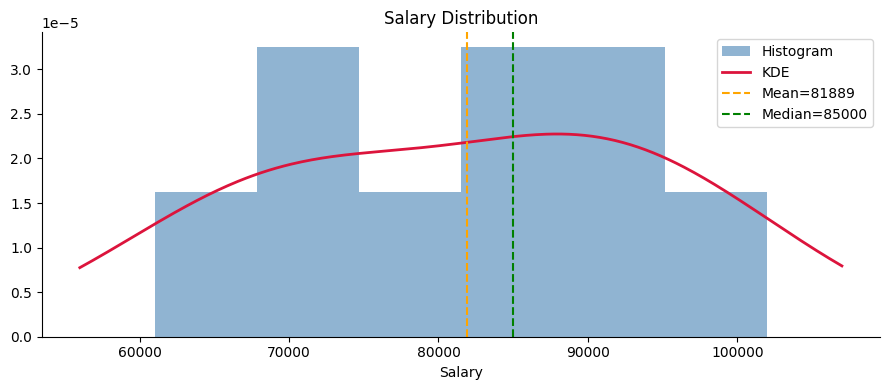

In [18]:
salary = df_filled['salary']

mean_s   = salary.mean()
median_s = salary.median()
std_s    = salary.std()
min_s    = salary.min()
max_s    = salary.max()
# IQR = 75th percentile - 25th percentile
iqr_s    = np.percentile(salary, 75) - np.percentile(salary, 25)

print(f"Mean:   {mean_s:.0f}")
print(f"Median: {median_s:.0f}")
print(f"Std:    {std_s:.0f}")
print(f"Range:  {min_s:.0f} – {max_s:.0f}")
print(f"IQR:    {iqr_s:.0f}")

# Histogram with KDE overlay
fig, ax = plt.subplots()
ax.hist(salary, bins=6, density=True, alpha=0.6, color='steelblue', label='Histogram')
# KDE: kernel density estimate gives smooth curve
xs = np.linspace(salary.min() - 5000, salary.max() + 5000, 300)
kde = stats.gaussian_kde(salary)
ax.plot(xs, kde(xs), color='crimson', lw=2, label='KDE')
ax.axvline(mean_s, color='orange', linestyle='--', label=f'Mean={mean_s:.0f}')
ax.axvline(median_s, color='green', linestyle='--', label=f'Median={median_s:.0f}')
ax.set_xlabel('Salary'); ax.set_title('Salary Distribution')
ax.legend()
plt.tight_layout(); plt.show()

**Definitions (5.1):**

- **Population:** The complete set of all individuals or observations of interest (e.g., every employee at the company).
- **Sample:** A subset of the population that we actually observe and measure (e.g., the 9 employees in our dataset).
- **Descriptive statistic:** A number that summarizes or describes a feature of a dataset (e.g., the mean salary of $82,500 describes the center of our data).
- **Inferential statistic:** A method that uses sample data to make conclusions or predictions about a larger population, including quantifying uncertainty (e.g., a t-test to decide if Engineering salaries are truly higher company-wide).

### 5.2 Hypothesis Testing

In [19]:
eng_salaries = df_filled[df_filled['department'] == 'Engineering']['salary']
overall_mean = df_filled['salary'].mean()

# One-sample t-test: tests if the sample mean differs from a known value (overall_mean)
t_stat, p_value = stats.ttest_1samp(eng_salaries, overall_mean)

print(f"Overall mean salary:      {overall_mean:.0f}")
print(f"Engineering mean salary:  {eng_salaries.mean():.0f}")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value:     {p_value:.4f}")
print(f"Reject H₀ at α=0.05? {p_value < 0.05}")

# Pearson correlation: measures linear relationship between two continuous variables
r, r_pval = stats.pearsonr(df_filled['salary'], df_filled['years_exp'])
print(f"\nPearson r (salary vs years_exp): {r:.4f}, p={r_pval:.4f}")

Overall mean salary:      81889
Engineering mean salary:  94000
t-statistic: 4.0002
p-value:     0.0280
Reject H₀ at α=0.05? True

Pearson r (salary vs years_exp): 0.0485, p=0.9015


**H₀ / H₁ and Interpretation (5.2):**

- **H₀ (Null Hypothesis):** Engineering salaries are equal to the overall company mean salary (μ_eng = μ_all). Any observed difference is due to random chance.
- **H₁ (Alternative Hypothesis):** Engineering salaries are significantly higher than the overall company mean salary (μ_eng > μ_all).
- **Conclusion:** If p-value < 0.05 we reject H₀ and conclude there is statistically significant evidence that Engineering salaries differ from the company average. The Pearson correlation between salary and years of experience tells us how strongly these two variables move together — a positive r means more experience tends to correlate with higher salary.

### 5.3 Error Metrics

In [20]:
y_true = np.array([3.0, 5.0, 2.5, 7.0, 4.5, 6.0, 1.5, 8.0])
y_pred = np.array([2.8, 5.2, 2.1, 7.5, 4.0, 6.3, 2.0, 7.8])
n, p = len(y_true), 2

# MAE: average absolute error — same units as target, robust to outliers
mae  = np.mean(np.abs(y_true - y_pred))

# MSE: average squared error — penalizes large errors more heavily
mse  = np.mean((y_true - y_pred) ** 2)

# RMSE: square root of MSE — back in original units
rmse = np.sqrt(mse)

# R²: proportion of variance explained — 1.0 is perfect, 0 = predicts mean only
ss_res = np.sum((y_true - y_pred) ** 2)          # residual sum of squares
ss_tot = np.sum((y_true - y_true.mean()) ** 2)   # total sum of squares
r2     = 1 - ss_res / ss_tot

# Adjusted R²: penalizes for adding extra features; better for model comparison
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f"MAE:        {mae:.4f}")
print(f"MSE:        {mse:.4f}")
print(f"RMSE:       {rmse:.4f}")
print(f"R²:         {r2:.4f}")
print(f"Adj. R²:    {adj_r2:.4f}")

MAE:        0.3500
MSE:        0.1400
RMSE:       0.3742
R²:         0.9689
Adj. R²:    0.9564


### 5.4 Distribution Testing & Stationarity

In [23]:
import statsmodels
print(statsmodels.__version__)

import numpy as np
from scipy import stats
from statsmodels.tsa.stattools import adfuller

# -----------------------------
# 1. Generate Sample Data
# -----------------------------
np.random.seed(0)

# Normal data
s1 = np.random.normal(0, 1, 200)

# Non-normal (exponential) data
s2 = np.random.exponential(1, 200)

# -----------------------------
# 2. Kolmogorov-Smirnov (KS) Test
# -----------------------------
print("===== KS TEST (Normality Check) =====")

# H0: Sample comes from N(0,1)
ks_s1 = stats.kstest(s1, 'norm')
ks_s2 = stats.kstest(s2, 'norm')

print(f"s1 (Normal Data):")
print(f"KS Statistic = {ks_s1.statistic:.4f}")
print(f"P-value      = {ks_s1.pvalue:.4f}")

if ks_s1.pvalue > 0.05:
    print("Conclusion: Data appears NORMAL")
else:
    print("Conclusion: Data is NOT normal")

print("\n---------------------------")

print("s2 (Exponential Data):")
print(f"KS Statistic = {ks_s2.statistic:.4f}")
print(f"P-value      = {ks_s2.pvalue:.4f}")

if ks_s2.pvalue > 0.05:
    print("Conclusion: Data appears NORMAL")
else:
    print("Conclusion: Data is NOT normal")

# -----------------------------
# 3. Create Non-Stationary Series
# -----------------------------
print("\n\n===== ADF TEST (Stationarity Check) =====")

t = np.arange(200)

# Trend + Noise
ts = 0.05 * t + np.random.normal(0, 1, 200)

# -----------------------------
# 4. ADF Test on Original Series
# -----------------------------
adf_result = adfuller(ts)

print("Original Time Series:")
print(f"ADF Statistic = {adf_result[0]:.4f}")
print(f"P-value       = {adf_result[1]:.4f}")

if adf_result[1] < 0.05:
    print("Conclusion: Series is STATIONARY")
else:
    print("Conclusion: Series is NON-STATIONARY")

# -----------------------------
# 5. First Differencing
# -----------------------------
ts_diff = np.diff(ts)

# -----------------------------
# 6. ADF Test After Differencing
# -----------------------------
adf_diff = adfuller(ts_diff)

print("\nAfter First Differencing:")
print(f"ADF Statistic = {adf_diff[0]:.4f}")
print(f"P-value       = {adf_diff[1]:.4f}")

if adf_diff[1] < 0.05:
    print("Conclusion: Series is STATIONARY")
else:
    print("Conclusion: Series is NON-STATIONARY")

0.14.6
===== KS TEST (Normality Check) =====
s1 (Normal Data):
KS Statistic = 0.0522
P-value      = 0.6268
Conclusion: Data appears NORMAL

---------------------------
s2 (Exponential Data):
KS Statistic = 0.5046
P-value      = 0.0000
Conclusion: Data is NOT normal


===== ADF TEST (Stationarity Check) =====
Original Time Series:
ADF Statistic = -0.9234
P-value       = 0.7802
Conclusion: Series is NON-STATIONARY

After First Differencing:
ADF Statistic = -8.4288
P-value       = 0.0000
Conclusion: Series is STATIONARY


### 5.5 Model Monitoring Concepts

In [ ]:
def compute_psi(expected, actual, bins=10):
    """
    Population Stability Index (PSI):
    PSI = Σ (actual_pct - expected_pct) × ln(actual_pct / expected_pct)
    
    Measures how much a distribution has shifted.
    """
    eps = 1e-10  # avoid log(0)
    # Create shared bin edges spanning both distributions
    min_val = min(expected.min(), actual.min())
    max_val = max(expected.max(), actual.max())
    breakpoints = np.linspace(min_val, max_val, bins + 1)
    
    # Compute proportion of observations in each bin
    exp_pct = np.histogram(expected, bins=breakpoints)[0] / len(expected)
    act_pct = np.histogram(actual,   bins=breakpoints)[0] / len(actual)
    
    # Replace zeros to avoid log(0)
    exp_pct = np.where(exp_pct == 0, eps, exp_pct)
    act_pct = np.where(act_pct == 0, eps, act_pct)
    
    psi = np.sum((act_pct - exp_pct) * np.log(act_pct / exp_pct))
    return psi

np.random.seed(1)
train_dist = np.random.normal(50, 10, 1000)   # training distribution
drift_dist = np.random.normal(65, 12, 1000)   # shifted production distribution

psi_value = compute_psi(train_dist, drift_dist)
print(f"PSI: {psi_value:.4f}")
print(f"Shift severity: {'Major' if psi_value > 0.2 else 'Minor' if psi_value > 0.1 else 'Stable'}")

# Plot both distributions
fig, ax = plt.subplots()
ax.hist(train_dist, bins=30, density=True, alpha=0.5, color='steelblue', label='Training (N(50,10))')
ax.hist(drift_dist, bins=30, density=True, alpha=0.5, color='crimson',   label='Production (N(65,12))')
ax.legend(); ax.set_title(f'Distribution Shift Visualization  (PSI = {psi_value:.3f})')
ax.set_xlabel('Feature Value')
plt.tight_layout(); plt.show()

**Concept Drift vs Covariate Drift & PSI Thresholds (5.5):**

- **Concept drift:** The relationship between input features X and the target y changes over time (e.g., customer behavior that defines "churn" changes). The model's learned mapping P(y|X) becomes outdated.
- **Covariate drift:** The distribution of input features P(X) shifts while the true relationship P(y|X) remains the same (e.g., a new customer segment starts using the product). This is what PSI measures.
- **PSI < 0.1:** No significant shift — distribution is stable, model is likely still valid.
- **PSI 0.1–0.2:** Minor shift — monitor closely, investigate which features are drifting.
- **PSI > 0.2:** Major shift — model performance likely degraded, immediate investigation and retraining required.
- **Retraining trigger example:** Schedule automated retraining when PSI > 0.2 on any top-5 most important feature, or when model accuracy on a held-out recent sample drops more than 5% from baseline.

---
## Part 6 — Probability Theory

### 6.1 Core Concepts

In [ ]:
total = 10
red, blue, green = 4, 3, 3

# Simple probability = favorable outcomes / total outcomes
p_red   = red   / total   # 4/10 = 0.4
p_blue  = blue  / total   # 3/10 = 0.3
p_green = green / total   # 3/10 = 0.3

# Joint probability WITHOUT replacement:
# P(red first AND blue second) = P(red first) × P(blue second | red first)
# After picking red: 9 marbles remain, 3 are blue
p_red_then_blue = (red / total) * (blue / (total - 1))  # 4/10 × 3/9

# Conditional probability:
# P(blue second | red first) = blue remaining / total remaining
p_blue_given_red = blue / (total - 1)   # 3/9

# Independence check: events A, B are independent iff P(B|A) == P(B)
# P(blue|red) = 3/9 ≈ 0.333   but   P(blue) = 3/10 = 0.3  → NOT equal
independent = (p_blue_given_red == p_blue)   # False — without replacement ≠ independent

print(f"Sample space: {{red×4, blue×3, green×3}} = 10 marbles")
print(f"P(red)={p_red:.3f}, P(blue)={p_blue:.3f}, P(green)={p_green:.3f}")
print(f"P(red,blue): {p_red_then_blue:.4f}  [= 4/10 × 3/9]")
print(f"P(blue|red): {p_blue_given_red:.4f}  [= 3/9]")
print(f"P(blue):     {p_blue:.4f}  [= 3/10]")
print(f"Independent? {independent}  ← P(blue|red) ≠ P(blue), so draws are DEPENDENT")

### 6.2 Distributions in the Wild

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ── Normal ──────────────────────────────────────────────────────────────────
x = np.linspace(-4, 6, 300)
axes[0].plot(x, stats.norm.pdf(x, 0, 1),   color='steelblue', lw=2, label='N(μ=0, σ=1)')
axes[0].plot(x, stats.norm.pdf(x, 2, 0.5), color='crimson',   lw=2, label='N(μ=2, σ=0.5)')
axes[0].legend(); axes[0].set_title('Normal Distribution')
axes[0].set_xlabel('x'); axes[0].set_ylabel('Probability Density')
# ML use case: models residuals/errors in linear regression; feature distributions after standardization

# ── Binomial ────────────────────────────────────────────────────────────────
k = np.arange(0, 21)
axes[1].bar(k - 0.2, stats.binom.pmf(k, 20, 0.5), width=0.35,
            color='steelblue', alpha=0.7, label='p=0.5')
axes[1].bar(k + 0.2, stats.binom.pmf(k, 20, 0.7), width=0.35,
            color='crimson',   alpha=0.7, label='p=0.7')
axes[1].legend(); axes[1].set_title('Binomial Distribution (n=20)')
axes[1].set_xlabel('k (number of successes)')
# ML use case: binary classification — probability of k positive predictions in n trials

# ── Poisson ─────────────────────────────────────────────────────────────────
k2 = np.arange(0, 16)
axes[2].bar(k2, stats.poisson.pmf(k2, mu=3), color='seagreen', alpha=0.8)
axes[2].set_title('Poisson Distribution (λ=3)')
axes[2].set_xlabel('k (number of events)')
# ML use case: modeling rare event counts — fraud transactions, server errors per hour

plt.tight_layout(); plt.show()

### 6.3 Bayes' Theorem

In [ ]:
p_spam            = 0.30
p_free_given_spam = 0.80
p_free_given_ham  = 0.05
p_ham             = 1 - p_spam   # 0.70

# P(free) via the law of total probability:
# P(free) = P(free|spam)×P(spam) + P(free|ham)×P(ham)
p_free = p_free_given_spam * p_spam + p_free_given_ham * p_ham

# Bayes' theorem: P(spam|free) = P(free|spam) × P(spam) / P(free)
p_spam_given_free = (p_free_given_spam * p_spam) / p_free

print(f"P('free'):          {p_free:.4f}")
print(f"P(Spam | 'free'):   {p_spam_given_free:.4f}")

def naive_bayes_predict(prior_spam, p_word_given_spam, p_word_given_ham):
    """Returns P(Spam | word) using Bayes' theorem."""
    p_ham_local = 1 - prior_spam
    p_word = p_word_given_spam * prior_spam + p_word_given_ham * p_ham_local
    return (p_word_given_spam * prior_spam) / p_word

pred = naive_bayes_predict(0.30, 0.80, 0.05)
assert abs(pred - p_spam_given_free) < 1e-9
print(f"naive_bayes_predict: {pred:.4f}")
print("6.3 passed ✓")

**Bayes Term Mapping (6.3):**

| Term | Formula | In this example |
|------|---------|------------------|
| Prior | P(Spam) | 0.30 — our belief that any email is spam *before* seeing the word "free" |
| Likelihood | P(word \| Spam) | 0.80 — how likely spam emails contain the word "free" |
| Evidence | P(word) | 0.275 — overall probability of seeing "free" in any email |
| Posterior | P(Spam \| word) | ≈ 0.873 — updated belief that email is spam *after* seeing "free" |

### 6.4 Central Limit Theorem

In [ ]:
np.random.seed(7)
population = np.random.exponential(scale=1.0, size=100_000)  # right-skewed population

n_samples   = 5000
sample_size = 30

# Draw 5000 samples of size 30 and record the mean of each
sample_means = np.array([
    np.random.choice(population, sample_size, replace=False).mean()
    for _ in range(n_samples)
])

pop_mean = population.mean()
pop_std  = population.std()
# CLT: std of sample means = population_std / sqrt(n)
clt_std  = pop_std / np.sqrt(sample_size)

print(f"Population mean: {pop_mean:.4f}, Population std: {pop_std:.4f}")
print(f"Sample means mean: {sample_means.mean():.4f}, std: {sample_means.std():.4f}")
print(f"CLT predicted std: {clt_std:.4f}")

# Plot: histogram of sample means + theoretical normal overlay
fig, ax = plt.subplots()
ax.hist(sample_means, bins=50, density=True, alpha=0.6,
        color='steelblue', label='Sample Means')
xs = np.linspace(sample_means.min(), sample_means.max(), 300)
ax.plot(xs, stats.norm.pdf(xs, pop_mean, clt_std),
        color='crimson', lw=2.5, label=f'N(μ={pop_mean:.2f}, σ={clt_std:.3f})')
ax.set_title('CLT: Distribution of Sample Means')
ax.set_xlabel('Sample Mean'); ax.legend()
plt.tight_layout(); plt.show()

# KS test to verify normality of sample means
ks_result = stats.kstest(sample_means, 'norm', args=(pop_mean, clt_std))
print(f"KS test p-value: {ks_result.pvalue:.4f} → Approximately normal? {ks_result.pvalue > 0.05}")

**CLT Reflection (6.4):**

The Central Limit Theorem states that regardless of the shape of the population distribution (in this case, exponential — heavily right-skewed), the distribution of sample means approaches a normal distribution as sample size increases. This result is foundational for statistics and ML because it justifies using z-tests, t-tests, and confidence intervals on real-world data that isn't normally distributed — we only need the *sample means* to be normal, not the raw data. In ML, it also underpins why ensemble methods (averaging many model predictions) tend to reduce variance: the average of many estimates converges to a stable, normally-distributed estimate of the true value.

---
## 🏁 Submission Checklist

- [x] All `assert` blocks pass without errors
- [x] All `# YOUR CODE HERE` cells are filled
- [x] All markdown reflection cells are filled in your own words
- [x] All plots render with labels and titles
- [x] Notebook runs cleanly from top to bottom (`Kernel → Restart & Run All`)

**Saved as:** `week1_solutions.ipynb`